In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import wandb
import torchvision
from tqdm import tqdm
import torch.nn.functional as F

sys.path.append(os.path.join(os.getcwd(), '../symlie'))
sys.path.append(os.path.join(os.getcwd(), '../'))

from symlie.model.networks.mlp import CombiMLP
from symlie.model.learner import CombiLearner
from symlie.run import parse_options, main, process_args

/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
args = parse_options(notebook=True)
# args.config = 'o5synth'
args.config = 'combi'
# args.do_return = True
args.logger = None

# args.implicit_layer_dims = [[0], [0]]
# args.implicit_layer_dims = [[100, 100, 100], [10, 10, 10]]
# args.implicit_layer_dims = [[110, 110, 110, 110], [11, 11, 11, 11]]
# args.implicit_layer_dims = [[110, 110], [11, 11]]
# args.grid_sizes = [[[1,2,5], [1,2,5]], [[1,1,1], [1,2,5]]]
args.bias = False
args.lossweight_o = 0.
args.lossweight_y = 1. #1e-6 #0.0000001

process_args(args)

# Training
model, trainer, datamodule = main(args)

Seed set to 1


Init rng
Running without logging
Print parameters in configure_optimizers
net.vanilla_layers.0.weight True
net.vanilla_layers.1.weight True

Testing DataLoader 0: 100%|██████████| 63/63 [00:00<00:00, 292.78it/s]
No logger, skipping logging


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    0.1328432559967041     │
│        test_loss_y        │    0.1328432559967041     │
└───────────────────────────┴───────────────────────────┘

In [11]:
args = parse_options(notebook=True)
# args.config = 'o5synth'
args.config = 'combi'
# args.do_return = True
args.logger = None

# args.implicit_layer_dims = [[0], [0]]
# args.implicit_layer_dims = [[100, 100, 100], [10, 10, 10]]
# args.implicit_layer_dims = [[110, 110, 110, 110], [11, 11, 11, 11]]
# args.implicit_layer_dims = [[110, 110], [11, 11]]
# args.grid_sizes = [[[1,2,5], [1,2,5]], [[1,1,1], [1,2,5]]]
args.bias = False
args.lossweight_o = 0.
args.lossweight_y = 1. #1e-6 #0.0000001

process_args(args)

# Training
model, trainer, datamodule = main(args)

Seed set to 1
/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:187: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Init rng
Running without logging
Print parameters in configure_optimizers
net.implicit_layers.0.implicit_layer.0.weight True
net.implicit_layers.0.implicit_layer.0.bias True
net.implicit_layers.0.implicit_layer.3.weight True
net.implicit_layers.0.implicit_layer.3.bias True
net.implicit_layers.0.implicit_layer.6.weight True
net.implicit_layers.0.implicit_layer.6.bias True
net.implicit_layers.1.implicit_layer.0.weight True
net.implicit_layers.1.implicit_layer.0.bias True
net.implicit_layers.1.implicit_layer.3.weight True
net.implicit_layers.1.implicit_layer.3.bias True
net.vanilla_layers.0.weight True
net.vanilla_layers.1.weight True

Testing DataLoader 0: 100%|██████████| 63/63 [00:00<00:00, 206.68it/s]
No logger, skipping logging


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    0.13252080976963043    │
│       test_loss_o0        │   7.576934176920739e-15   │
│       test_loss_o1        │   2.923508594701563e-15   │
│        test_loss_y        │    0.13252080976963043    │
└───────────────────────────┴───────────────────────────┘

In [4]:
args = parse_options(notebook=True)
args.config = 'o5synth'
# args.do_return = True
# args.logger = None

# args.implicit_layer_dims = [[0], [0]]
# args.implicit_layer_dims = [[100, 100, 100], [10, 10, 10]]
args.implicit_layer_dims = [[110, 110, 110, 110], [11, 11, 11, 11]]
# args.implicit_layer_dims = [[110, 110], [11, 11]]
args.grid_sizes = [[[1,2,5], [1,2,5]], [[1,1,1], [1,2,5]]]
args.bias = True
args.lossweight_o = 1.
args.lossweight_y = 1. #1e-6 #0.0000001

process_args(args)

# Training
model, trainer, datamodule = main(args)

Seed set to 1
/Users/elias/EliasMBA/Projects/Uni/SymPDE/notebooks_symlie/../symlie/data/dataset.py:62: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3618.)
  self.y = torch.stack([self.y*(1+y_range_i) for y_range_i in range(args.y_multi)]).T


Init rng
Running without logging
Print parameters in configure_optimizers
net.implicit_layers.0.implicit_layer.0.weight True
net.implicit_layers.0.implicit_layer.0.bias True
net.implicit_layers.0.implicit_layer.3.weight True
net.implicit_layers.0.implicit_layer.3.bias True
net.implicit_layers.0.implicit_layer.6.weight True
net.implicit_layers.0.implicit_layer.6.bias True
net.implicit_layers.1.implicit_layer.0.weight True
net.implicit_layers.1.implicit_layer.0.bias True
net.implicit_layers.1.implicit_layer.3.weight True
net.implicit_layers.1.implicit_layer.3.bias True
net.implicit_layers.1.implicit_layer.6.weight True
net.implicit_layers.1.implicit_layer.6.bias True
net.vanilla_layers.0.weight True
net.vanilla_layers.0.bias True
net.vanilla_layers.1.weight True
net.vanilla_layers.1.bias True

Testing: |          | 63/? [00:08<00:00,  7.03it/s]96it/s, val_loss_y=73.30, val_loss_o0=7.52e-17, val_loss_o1=7.99e-15, val_loss=8.07e-15, train_loss_y=74.10, train_loss_o0=7.68e-17, train_loss_o1

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │   7.770493910862555e-15   │
│       test_loss_o0        │   7.265334446078625e-17   │
│       test_loss_o1        │   7.69784220091066e-15    │
│        test_loss_y        │     82.51168060302734     │
└───────────────────────────┴───────────────────────────┘

In [3]:
x, y, _ = batch = next(iter(datamodule.train_dataloader()))

In [ ]:
# def get_y(x):
#     ri = x.reshape(-1,2,5)
#     r1,r2 = ri.transpose(1,0,2)
#     y = np.sin(np.sqrt((r1**2).sum(-1)))-.5*np.sqrt((r2**2).sum(-1))**3 + (r1*r2).sum(-1)/(np.sqrt((r1**2).sum(-1))*np.sqrt((r2**2).sum(-1)))
#     return y

# np.allclose( get_y(x.numpy()), y.reshape(-1).numpy() )
# y

tensor([[0.0744, 0.0744, 0.0744, 0.0744, 0.0744, 0.0744, 0.0744]],
       grad_fn=<ViewBackward0>)


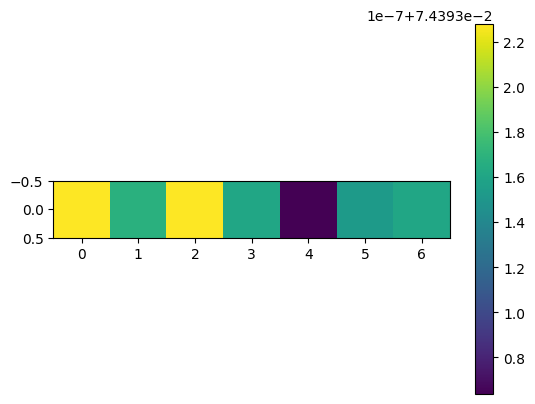

In [10]:
w, b = model.net.implicit_layers[1](
    model.net.vanilla_layers[1].weight.data.clone(), None
)

print(w)
plt.imshow(w.detach())
plt.colorbar()
plt.show()

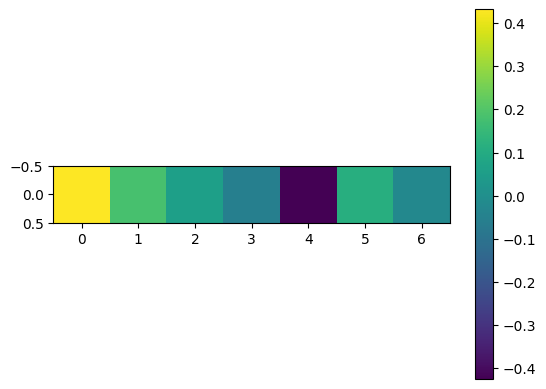

In [3]:
w, b = model.net.implicit_layers[1](
    model.net.vanilla_layers[1].weight.data.clone(), None
)

print
plt.imshow(w.detach())
plt.colorbar()
plt.show()

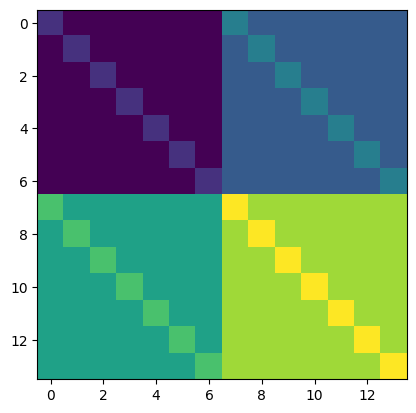

In [27]:
nn = 7

i1 = torch.zeros(nn)
i1[0] = 1
i2 = torch.cat([i1])
i3 = torch.stack([torch.roll(i2, j, 0) for j in range(nn)])
i4 = i3 + 2
i5 = torch.cat([i3, i4], dim=1)
i6 = i5 + 4
wp = torch.cat([i5, i6], dim=0)

plt.imshow(wp)

In [25]:
wp.shape

torch.Size([49, 49])

In [ ]:
def get_space_translation(size):
    w1 = torch.zeros(size)
    w1[0] = 1.
    w2 = torch.stack([torch.roll(w1, shifts = shift) for shift in range(size)])
    w3 = torch.cat([torch.roll(w2, shifts = (shift, 0), dims = (0,1)) for shift in range(size)])

    w_index = torch.zeros(size**2, size**2)
    w_index[:, :size] = w3
    return w_index


w = torch.randn(1,7)
w = ( wp @ w.flatten() ).reshape(w.shape)
plt.imshow(w)

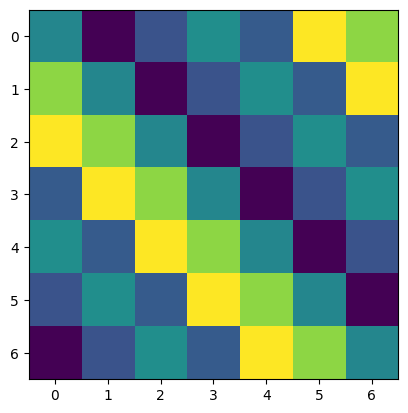

In [30]:



w = torch.randn(7,7)
w = ( wp @ w.flatten() ).reshape(w.shape)
plt.imshow(w)

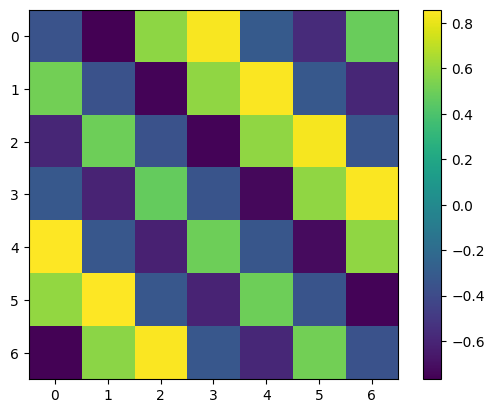

In [18]:
w, b = model.net.implicit_layers[0](
    model.net.vanilla_layers[0].weight.data.clone(), None
)

plt.imshow(w.detach())
plt.colorbar()
plt.show()

In [7]:
w, b = model.net.implicit_layers[0](
    model.net.vanilla_layers[0].weight.data.clone(),  model.net.vanilla_layers[0].bias.data.clone()
)

plt.imshow(w.detach())
plt.colorbar()
w

AttributeError: 'NoneType' object has no attribute 'data'

torch.Size([10, 10]) torch.Size([10, 1])


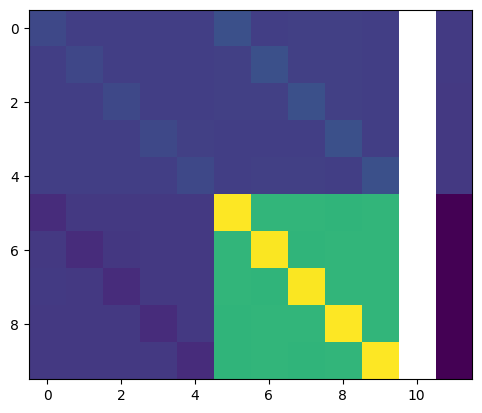

In [11]:
def wb_plot_pred(w, b):
    b = b.view(-1, 1)

    print(w.shape, b.shape)

    return torch.cat([
        w,
        torch.full_like(b, torch.nan),
        b,
    ], dim = 1).detach().numpy()

plt.imshow(wb_plot_pred(w, b))
plt.show()

In [ ]:
args = parse_options(notebook=True)
args.config = 'o5synth'
# args.do_return = True
# args.logger = None

args.implicit_layer_dims = [[0], [0]]
args.bias = True
args.lossweight_o = 0.

process_args(args)

# Training
model, trainer, datamodule = main(args)

In [5]:
args = parse_options(notebook=True)
# args.config = 'emlp'
args.config = 'emlp_mlp'
# args.do_return = True
# args.logger = None
args.bias = True
args.lossweight_o = 0.
process_args(args)

# Training
main(args)
# model, trainer, datamodule = main(args)

Seed set to 1


(V+V) V⁰ O(5) [10]
Init rng


/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:389: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:187: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Running easy-pyramid-3089 with id cwomyp7f
Print parameters in configure_optimizers
net.net.0.0.weight True
net.net.0.0.bias True
net.net.1.weight True
net.net.1.bias True

Testing DataLoader 0: 100%|██████████| 63/63 [00:00<00:00, 687.91it/s]
Logged regression results


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    30.010055541992188     │
│        test_loss_y        │    30.010055541992188     │
└───────────────────────────┴───────────────────────────┘

wandb: WARNING Source type is set to 'repo' but some required information is missing from the environment. A job will not be created from this run. See https://docs.wandb.ai/guides/launch/create-job


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
test_loss,▁
test_loss_y,▁
train_loss,█▇▇▆▅▅▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
train_loss_y,█▇▇▆▅▅▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
val_loss,█▇▇▆▅▅▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_loss_y,█▇▇▆▅▅▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
epoch,50
test_loss,30.01006
test_loss_y,30.01006


(CombiLearner(
   (net): EMLP_MLP_wrapper(
     (net): Sequential(
       (0): Sequential(
         (0): Linear(in_features=10, out_features=10, bias=True)
         (1): ReLU()
       )
       (1): Linear(in_features=10, out_features=1, bias=True)
     )
   )
 ),
 <data.datamodule.BaseDataModule at 0x2e0c5c280>)

In [ ]:
from emlp.nn.pytorch import EMLPBlock
from emlp.nn.pytorch import Linear as EMLP_Linear
from emlp.reps import V, T, vis
from emlp.groups import Z, O
from emlp.datasets import O5Synthetic
from emlp.reps import T,Rep,Scalar
from emlp.nn import gated,gate_indices,uniform_rep

from emlp.nn.pytorch import EMLP, Linear as EMLP_Linear, BiLinear as EMLP_BiLinear, GatedNonlinearity
from symlie.model.networks.mlp import EMLP_wrapper


In [ ]:
set = O5Synthetic(N = 1)
group, repin, repout = O(5), set.rep_in, set.rep_out
repin, repout = repin(group), repout(group)

In [ ]:
vis(repin, repin)

In [ ]:
gated(repin)

In [ ]:
repin

In [ ]:
vis(gated(repin), gated(repin))

In [ ]:
model = EMLP_wrapper(
    implicit_layer_dims = [],
    vanilla_layer_dims = [10, 10, 1],
    bias = True,
    repin = repin,
    repout = repout,
    group = group,
)

In [ ]:
r1 = repin
r2 = uniform_rep(10, group)

linear = EMLP_Linear(r1, gated(r2))

# vis(r1, gated(r2))
vis(gated(r2), gated(r2))

# plt.imshow( linear.proj_b(linear.weight).detach() )




In [ ]:
r2

In [ ]:
gated(r2)

In [ ]:
p00 = (p0*1).to(torch.int)

p00 = p00.to(torch.int)


In [ ]:
p = torch.full((10, 10), -1)
p0 = torch.eye(5)
p[:5,:5] += (p0*1).to(torch.int)
p[5:,5:] += (p0*2).to(torch.int)
p[:5,5:] += (p0*3).to(torch.int)
p[5:,:5] += (p0*4).to(torch.int)

plt.imshow(p)
print(p)

In [ ]:
w = torch.randn(10, 10)

wp = torch.tensor([w.flatten()[p_i].item() if p_i != -1 else 0 for p_i in p.flatten()]).reshape(10,10)
plt.imshow(wp)
print(wp)

In [ ]:
for c in [10]:
    if isinstance(c, Rep):
        cc = c(group)
    else:
        cc =uniform_rep(c, group)
        print('uniform')
    print(cc)

reps = [repin, cc]
reps

In [ ]:
x_d = torch.tensor([11, 12, 13, 14, 15, 21, 22, 23, 24, 25]).view(1, 10)
x_d

In [ ]:
rng_a, rng_b, rng_d = torch.Generator(), torch.Generator(), torch.Generator()

In [ ]:
b = EMLPBlock(reps[0], reps[1])
b = EMLP_Linear(reps[0], reps[1])

b = lambda x: F.linear(x, wp)

In [ ]:
from symlie.data.transforms import TransformRefactored

transform = TransformRefactored()


rng_b.set_state(rng_a.get_state())
rng_d.set_state(rng_a.get_state())

x_a, x_b = x.clone(), x.clone()

out_d_prime = transform.transform(x_d, rng_d, shape = (1, 2, 5))
print(out_d_prime)


out_a = b(x_a)
out_a_prime = transform.transform(out_a, rng_a, shape = (1, 2, 5))

x_b_prime = transform.transform(x_b, rng_b, shape = (1, 2, 5))
out_b_prime = b(x_b_prime)

print(torch.allclose(out_a_prime, out_b_prime))
(out_a_prime - out_b_prime)[0]



In [ ]:
out_a_prime.shape, out_b_prime.shape

In [ ]:
transform.transform(x, torch.Generator(), shape = (1, 2, 5))

In [ ]:
tran

In [ ]:
x.shape

In [ ]:
b(x).shape

In [ ]:
args = parse_options(notebook=True)
args.config = 'emlp_mlp'
# args.do_return = True
args.logger = None
args.bias = True
args.lossweight_o = 0.
process_args(args)

# Training
model, trainer, datamodule = main(args)

In [ ]:
# from symlie.data.transforms import RandomScale, CustomRandomRotation, SpaceTranslate
# from typing import List, Union

# class RandomPermute():
#     def __init__(self, dim: int):
#         self.dim = dim
#         assert self.dim == 3, "Only dim = 3 is supported"

#     def __call__(self, x, rng):
#         return x[:, :, :, torch.randperm(x.shape[self.dim], generator=rng)]

# class TransformRefactored:
#     def __init__(self, eps_mult: List[float] = [1., 1., 1., 1.]):
#         self.eps_mult = torch.tensor(eps_mult)

#         self.scale = RandomScale()
#         self.rotate = CustomRandomRotation(only_flip = False)
#         self.space_translate_x = SpaceTranslate(dim = 2)
#         self.space_translate_y = SpaceTranslate(dim = 1)

#         self.random_permute = RandomPermute(dim = 3)

#     def transform(self, x, rng, shape):

#         epsilons = self.eps_mult

#         batch_size, features = x.shape
#         x = x.reshape(batch_size, *shape)

#         # x = self.scale(x, epsilons[0])

#         # x = self.rotate(x, epsilons[1])

#         # x, _ = self.space_translate_x(x, epsilons[2])
#         # x, _ = self.space_translate_y(x, epsilons[3])

#         x = self.random_permute(x, rng)

#         x = x.reshape(batch_size, features)

#         return x
    
# rng = torch.Generator() # Create a random number generator
# rng_b = torch.Generator() # Create a random number generator
# # rng_b = rng_b.manual_seed(rng.seed())

    


In [ ]:
# xa = torch.randn(2, 6)
# # xb = torch.randn(2, 6)
# xb = xa.clone()

# eps = torch.randn(4)

# shape = (1, 2, 3)

# transform = TransformRefactored(eps_mult = [0, 0, 1, 0])

# xa_prime = transform.transform(xa, rng, shape)

# # rng_b = rng_b.set_state(rng.get_state())
# xb_prime = transform.transform(xb, rng_b, shape)

# print(torch.allclose(xa_prime, xb_prime))
# xa, xa_prime, xb, xb_prime

In [ ]:
from emlp.datasets import O5Synthetic
from emlp.reps import V, vis
from emlp.groups import Z, O, SO

from torch.utils.data import DataLoader


In [ ]:
set = O5Synthetic(N = 20)

In [ ]:
plt.plot(set[0][0])

In [ ]:
N = 5
d=5
dim = 2*d
X = np.random.randn(N,dim)

ri = X.reshape(-1,2,5)
r1,r2 = ri.transpose(1,0,2)

def y_org(r1, r2):
    return np.sin(np.sqrt((r1**2).sum(-1)))-.5*np.sqrt((r2**2).sum(-1))**3 + (r1*r2).sum(-1)/(np.sqrt((r1**2).sum(-1))*np.sqrt((r2**2).sum(-1)))

def y_new(r1, r2):
    sin = np.sin(np.sqrt((r1**2).sum(-1)))
    abs = -.5*np.sqrt((r2**2).sum(-1))**3
    dot = (r1*r2).sum(-1)/(np.sqrt((r1**2).sum(-1))*np.sqrt((r2**2).sum(-1)))
    return sin + abs + dot


r1_new, r2_new = shuffle(r1), shuffle(r2)
np.allclose(y_org(r1, r2), y_new(r1_new, r2_new))


In [ ]:
r1

In [ ]:
def shuffle(X):
    return np.take(X,np.random.permutation(X.shape[0]),axis=1,out=X)

shuffle(r1)

In [ ]:
set.rep_out

In [ ]:
V

In [ ]:
group, repin, repout = O(3), set.rep_in, set.rep_out
print(group, repin, repout)
repin, repout = V + V, V ** 9
print(group, repin, repout)
repin, repout = repin(group), repout(group)
print(group, repin, repout)

vis(repin, repin)

In [ ]:
group = Z(5)

repin, repout = V(group), V(group)
vis(repin, repout)